In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import functional as F
import tqdm
from matplotlib import pyplot as plt

In [2]:
# The little Shakespeare dataset 
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-01-17 18:54:04--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.06s   

2026-01-17 18:54:04 (18.6 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [3]:
# read the data in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print(f'Text size: {len(text)}')
print('Text example:')
print(text[:300])

Text size: 1115394
Text example:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [5]:
# use sybmols as tokens
# decode and encode functions use number of the sybol in sorted order
vocab = sorted(list(set(text)))

stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}

encode = lambda s: [stoi[ch] for ch in s]
decode = lambda a: ''.join([itos[i] for i in a])

In [6]:
print(vocab)

s = 'hello world'
print(encode(s))
print(decode(encode(s)))

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
[46, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]
hello world


In [7]:
# prepare train and validation data
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [8]:
train_data[:100]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])

In [9]:
torch.manual_seed(1337)

def generate_batch(batch_size: int, block_size: int, device: str, split='train') -> torch.Tensor:
    data = train_data if split == 'train' else val_data
    idx = torch.randint(len(data) - block_size, (batch_size, ))
    x = torch.stack([data[i:i + block_size] for i in idx])
    x = x.to(device)
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in idx])
    y = y.to(device)
    return x, y

In [10]:
vocab_size = len(vocab)
batch_size = 32
block_size = 32
model_size = 128
heads_number = 8
layers_number = 4

In [17]:
class MaskedAttention(nn.Module):

    def __init__(self, model_size, head_size, block_size, device):
        super().__init__()

        self.query = nn.Linear(model_size, head_size)
        self.key = nn.Linear(model_size, head_size)
        self.value = nn.Linear(model_size, head_size)
        self.dropout = nn.Dropout(0.1)
        self.model_size = model_size
        self.tril = torch.tril(
            torch.ones((block_size, block_size),
                       dtype=torch.float, device=device))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, model_size = x.shape
        q = self.query(x) # (B, T, head_size)
        k = self.key(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)

        weights = q @ k.transpose(1, 2) / self.model_size**0.5 # (B, T, T)
        weights = torch.masked_fill(weights, self.tril[:T, :T] == 0, float('-inf'))
        weights = torch.softmax(weights, dim=-1)
        weights = self.dropout(weights)
        
        out = weights @ v # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):

    def __init__(self, model_size, heads_number, block_size, device):
        super().__init__()

        head_size = model_size // heads_number
        self.attention_blocks = nn.ModuleList([
            MaskedAttention(model_size, head_size, block_size, device) 
            for _ in range(heads_number)])
        self.projection = nn.Linear(model_size, model_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        blocks_out = torch.cat([att(x) for att in self.attention_blocks], dim=-1)
        out = self.projection(blocks_out)
        return out

        

class FeedForward(nn.Module):

    def __init__(self, model_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(model_size, model_size),
            nn.ReLU(),
            nn.Linear(model_size, model_size))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):

    def __init__(self, block_size, model_size, heads_number, device):
        super().__init__()

        self.self_attention = MultiHeadAttention(model_size, heads_number, block_size, device)
        self.layer_norm_sa = nn.LayerNorm(model_size)
        self.layer_norm_ffn = nn.LayerNorm(model_size)
        self.ffn = FeedForward(model_size)

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sa_out = x + self.self_attention(self.layer_norm_sa(x))
        ffn_out = sa_out + self.ffn(self.layer_norm_ffn(sa_out))
        return ffn_out


class TinyShakespearModel(nn.Module):

    def __init__(self, device):
        super().__init__()
        
        # Token embedings
        self.token_embeddings_table = nn.Embedding(vocab_size, model_size, device=device)

        self.positions = torch.arange(model_size, device=device)
        # Learned position encoding
        self.position_embeddings_table = nn.Embedding(block_size, model_size, device=device)
        # Fixed position encoding
        self.position_encoding = self.get_position_encoding(block_size, model_size, device)

        # Model blocks
        self.block = nn.Sequential(
            *[Block(block_size, model_size, heads_number, device) 
              for _ in range(layers_number)])
        self.lm_head = nn.Linear(model_size, vocab_size)


    def get_position_encoding(self, block_size, model_size: int, device: int) -> torch.Tensor:
        dim_term = torch.exp(
            torch.arange(0, block_size // 2, device=device)
            * -(torch.log(torch.tensor(10000.0, device=device)) / model_size)
        )

        encodings = torch.zeros(block_size, model_size, device=device)
        encodings[:, 0::2] = torch.sin(self.positions * dim_term)
        encodings[:, 1::2] = torch.cos(self.positions * dim_term)
        return encodings

        
    def forward(self, x: torch.Tensor, targets: torch.Tensor | None = None) -> torch.Tensor:
        B, T = x.shape

        token_emb = self.token_embeddings_table(x) # (B, T, D)

        # We use learned position encoding here
        position_emb = self.position_embeddings_table(self.positions[:T]) # (T, D)

        logits = self.lm_head(self.block(token_emb + position_emb)) 

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))

        return logits, loss


    def generate(self, x: torch.Tensor, tokens_number: int) -> torch.Tensor:
        for _ in range(tokens_number):
            x_block = x[:, -block_size:]
            logits, loss = self(x_block)
            # take only the last predictions
            last_token_logits = logits[:, -1, :]
            # get probabilities
            probs = F.softmax(last_token_logits, dim=-1)
            # sample new token from the distribution
            new_token = torch.multinomial(probs, num_samples=1)
            x = torch.cat((x, new_token), dim=1)
        return x

In [18]:
# creating a model
device = 'cuda:0'
model = TinyShakespearModel(device)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [19]:
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

0.419137 M parameters


In [20]:
# training the model
steps = 15000
losses = []
val_losses = []

for i in tqdm.tqdm(range(steps)):
    x, y = generate_batch(batch_size, block_size, device, split='train')
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    with torch.no_grad():
        x, y = generate_batch(batch_size, block_size, device, split='val')
        logits, loss = model(x, y)
        val_losses.append(loss.item())

100%|██████████| 15000/15000 [13:23<00:00, 18.66it/s]


In [21]:
print('train loss', losses[-1], 'val loss', val_losses[-1])

train loss 1.4187805652618408 val loss 1.6111676692962646


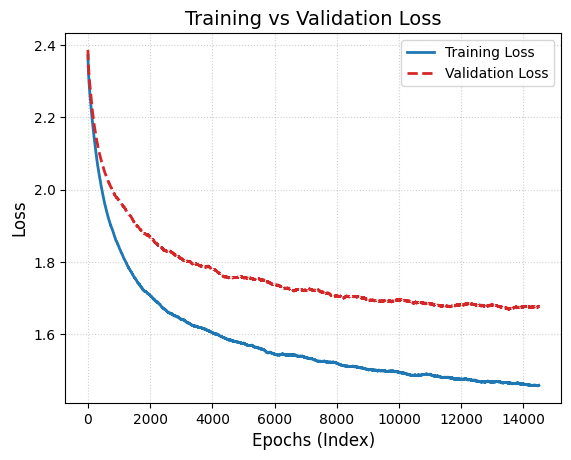

In [22]:
N = 500
rolling_avg_losses = np.convolve(losses, np.ones(N)/N, mode='valid')
rolling_avg_val_losses = np.convolve(val_losses, np.ones(N)/N, mode='valid')

epochs = range(len(rolling_avg_losses)) 

plt.plot(epochs, rolling_avg_losses, label='Training Loss', color='tab:blue', linewidth=2)
plt.plot(epochs, rolling_avg_val_losses, label='Validation Loss', color='tab:red', linestyle='--', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [23]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, tokens_number=1000)[0].tolist()))



DUCHESS OF YORK:
Or of would hither of the servost of dealhus.

LADY CAPULET:
The still of you:
He now is so.

ELBOW:
O, but every's body awar, horses,
The hours we thou hast year, my fathat,
When the years of from than over,
The sens of abroies that him have been
Now from Rome to speak!
I not sight.

CORIOLANUS:
To now!
And, pribble cleavy him; If hold I have trises
In time there!--look to our a dalate
would cause to a chassage you prothee.

AUTOLYCUS:
Of what of lies crowns you:
Vittral-lot send our! 'Tis nothing people fawl taste what I do theem.

QUEEN MARGARELEY:
O.

KING RICHARD II:
And Julists that thom they notice, a sigh'd sakes from our father,
As will inch issue at again to his chole
world order faiserous refees: visit our offererer, I'll hath bothing  seas,
But for this is their maid. Why hatho'st
medici-diverringed dustirage, hons, thu art,
but could my nature accoint thou near,
Unless my, depenied now? blood, and that Autrain
As at makes Marianareties like in the reatwe

100%|██████████| 200/200 [00:08<00:00, 24.02it/s]


overfit loss 0.00022087809338700026


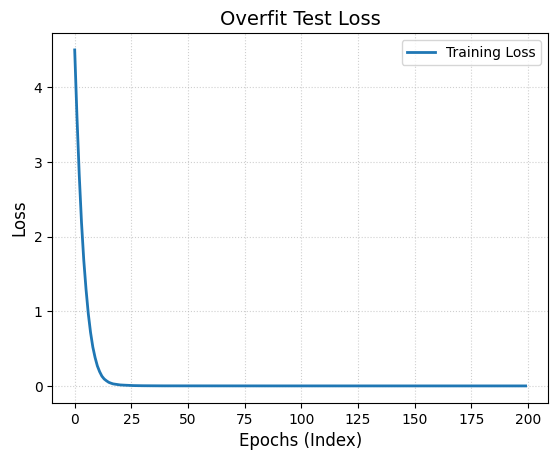

In [24]:
# overfit test
overfit_device = 'cpu'
m = TinyShakespearModel(overfit_device)
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
x, y = generate_batch(1, block_size, overfit_device)
steps = 200

losses_overfit = []
for _ in tqdm.tqdm(range(steps)):
    logits, loss = m(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses_overfit.append(loss.item())

print('overfit loss', losses_overfit[-1])

epochs = range(len(losses_overfit)) 

plt.plot(epochs, losses_overfit, label='Training Loss', color='tab:blue', linewidth=2)

plt.title('Overfit Test Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [25]:
from torchinfo import summary

x, y = generate_batch(batch_size, block_size, device)
summary(model, input_data=x)

Layer (type:depth-idx)                             Output Shape              Param #
TinyShakespearModel                                [32, 32, 65]              --
├─Embedding: 1-1                                   [32, 32, 128]             8,320
├─Embedding: 1-2                                   [32, 128]                 4,096
├─Sequential: 1-3                                  [32, 32, 128]             --
│    └─Block: 2-1                                  [32, 32, 128]             --
│    │    └─LayerNorm: 3-1                         [32, 32, 128]             256
│    │    └─MultiHeadAttention: 3-2                [32, 32, 128]             66,048
│    │    └─LayerNorm: 3-3                         [32, 32, 128]             256
│    │    └─FeedForward: 3-4                       [32, 32, 128]             33,024
│    └─Block: 2-2                                  [32, 32, 128]             --
│    │    └─LayerNorm: 3-5                         [32, 32, 128]             256
│    │    └─MultiH